<div align='center'>
    <h1>Implementing a Fuzzy Logic System to Evaluate Video Game Performance Based on Metadata and Platform Distribution Featur</h1>
    <h3>DKA PROJECT by STEPMTOHER LOVER</h3>
</div>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
data_games   = pd.read_csv('./Dataset/games_metadata_5k.csv')
data_ratings = pd.read_csv('./Dataset/game_ratings.csv')

# Pre-aggregate user ratings per game: avg rating (1-5) and count (capped at 100)
agg_ratings = data_ratings.groupby('game_id').agg(
    avg_user_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()
agg_ratings['rating_count'] = agg_ratings['rating_count'].clip(upper=100)

# Merge into metadata; fall back to global rating if no user ratings exist
data_games = data_games.merge(agg_ratings, on='game_id', how='left')
data_games['avg_user_rating'] = data_games['avg_user_rating'].fillna(data_games['rating'])
data_games['rating_count']    = data_games['rating_count'].fillna(0)


---
## 1. Fuzzification

In [3]:
#manual trimf helper that replicates skfuzzy's bitch ass
def trimf(x, abc):
    """
    Replicates skfuzzy.trimf mathematically.
    abc is a list/tuple of three points [a, b, c].
    """
    a, b, c = abc
    
    # Handle edge cases for flat/half-triangles at boundaries
    if a == b:
        # Downward slope from b to c
        return np.where(x < b, 0.0, np.where(x <= c, (c - x) / (c - b), 0.0))
    if b == c:
        # Upward slope from a to b
        return np.where(x < a, 0.0, np.where(x <= b, (x - a) / (b - a), 0.0))
        
    # Standard triangle
    first_half = (x - a) / (b - a)
    second_half = (c - x) / (c - b)
    return np.maximum(0, np.minimum(first_half, second_half))


In [4]:
#Define the universe 
x_global = np.linspace(0, 5, 500)
x_avg_user_rating = np.linspace(1, 5, 500)
x_rating_count =np.linspace(0, 100, 500)
x_platform = np.linspace(1, 22, 500)
x_recent = np.linspace(0, 10, 500)
x_recommendation = np.linspace(0, 10, 500)

In [5]:
#Membership function 
mf_global = {
    'Poor'    : trimf(x_global, [0, 0, 2.5]),
    'Average' : trimf(x_global, [1.5, 2.5, 3.5]),
    'High'    : trimf(x_global, [3, 5, 5]),
}
mf_avg_rating = {
    'Low'    : trimf(x_avg_user_rating, [1, 1, 3]), 
    'Medium' : trimf(x_avg_user_rating, [2, 3, 4]), 
    'High'   : trimf(x_avg_user_rating, [3, 5, 5]),
}
mf_count = {
    'Few'      : trimf(x_rating_count, [0, 0, 40]),
    'Moderate' : trimf(x_rating_count, [20, 50, 80]), 
    'Many'     : trimf(x_rating_count, [60, 100, 100]),
}
mf_platform = {
    'Narrow' : trimf(x_platform, [1, 1, 6]), 
    'Medium' : trimf(x_platform, [3, 7, 12]), 
    'Wide'   : trimf(x_platform, [8, 22, 22]),
}
mf_recent = {
    'Old'    : trimf(x_recent, [0, 0, 4]), 
    'Recent' : trimf(x_recent, [3, 5, 7]), 
    'New'    : trimf(x_recent, [6, 10, 10]), 
}
mf_recommendation = {
    'Poor'      : trimf(x_recommendation, [0, 0, 4]), 
    'Fair'      : trimf(x_recommendation, [3, 5, 7]),
    'Excellent' : trimf(x_recommendation, [6, 10, 10]),
}

In [6]:
#Fuzzify helper - converts crisp inputs into membership degrees
def fuzzify(global_in, avg_rating_in, count_in, platform_in, recent_in):
    return {
        'global': {
            'Poor'    : float(trimf(global_in, [0,   0,   2.5])),
            'Average' : float(trimf(global_in, [1.5, 2.5, 3.5])),
            'High'    : float(trimf(global_in, [3,   5,   5  ])),
        },
        'avg_rating': {
            'Low'    : float(trimf(avg_rating_in, [1, 1, 3])),
            'Medium' : float(trimf(avg_rating_in, [2, 3, 4])),
            'High'   : float(trimf(avg_rating_in, [3, 5, 5])),
        },
        'count': {
            'Few'      : float(trimf(count_in, [0,  0,   40 ])),
            'Moderate' : float(trimf(count_in, [20, 50,  80 ])),
            'Many'     : float(trimf(count_in, [60, 100, 100])),
        },
        'platform': {
            'Narrow' : float(trimf(platform_in, [1, 1,  6 ])),
            'Medium' : float(trimf(platform_in, [3, 7,  12])),
            'Wide'   : float(trimf(platform_in, [8, 22, 22])),
        },
        'recent': {
            'Old'    : float(trimf(recent_in, [0, 0,  4 ])),
            'Recent' : float(trimf(recent_in, [3, 5,  7 ])),
            'New'    : float(trimf(recent_in, [6, 10, 10])),
        },
    }


#Sanity check
sample_fv = fuzzify(4.5, 4.8, 85, 18, 9)
for var, degrees in sample_fv.items():
    print(f'{var:12s}:', {k: round(v, 3) for k, v in degrees.items()})

global      : {'Poor': 0.0, 'Average': 0.0, 'High': 0.75}
avg_rating  : {'Low': 0.0, 'Medium': 0.0, 'High': 0.9}
count       : {'Few': 0.0, 'Moderate': 0.0, 'Many': 0.625}
platform    : {'Narrow': 0.0, 'Medium': 0.0, 'Wide': 0.714}
recent      : {'Old': 0.0, 'Recent': 0.0, 'New': 0.75}


In [7]:
#rules and stuff 
def fuzzy_and(*args): 
    return min(args)
def fuzzy_or(*args): 
    return max(args)

def rule(fuzzyValues) : 
    poor_rules = [
        fuzzy_or(fuzzyValues['global']['Poor'], fuzzyValues['avg_rating']['Low']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['avg_rating']['Low'], fuzzyValues['platform']['Narrow']),
        fuzzy_and(fuzzyValues['recent']['Old'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['avg_rating']['Low'], fuzzyValues['recent']['Old']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['platform']['Narrow']),
        fuzzy_and(fuzzyValues['avg_rating']['Low'], fuzzyValues['count']['Few'])
        ]
    
    decent_rules = [
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['avg_rating']['Medium']),
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['count']['Moderate']),
        fuzzy_and(fuzzyValues['avg_rating']['Medium'], fuzzyValues['count']['Moderate']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['avg_rating']['Medium'], fuzzyValues['platform']['Medium']),
        fuzzy_and(fuzzyValues['recent']['Recent'], fuzzyValues['avg_rating']['Medium']),
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['platform']['Medium'])
    ]

    excellent_rules = [
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['recent']['New'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many'], fuzzyValues['recent']['New']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['platform']['Wide'])
    ]
    return {
        'Poor': max(poor_rules),
        'Decent' : max(decent_rules), 
        'Excellent' : max(excellent_rules)
    }

#Testin 
fuzzyValues = fuzzify(
    global_in=4.2,
    avg_rating_in=4.0,
    count_in=85,
    platform_in=15,
    recent_in=8
)

rule_strengths = rule(fuzzyValues)
print(rule_strengths)


{'Poor': 0.0, 'Decent': 0.0, 'Excellent': 0.5}


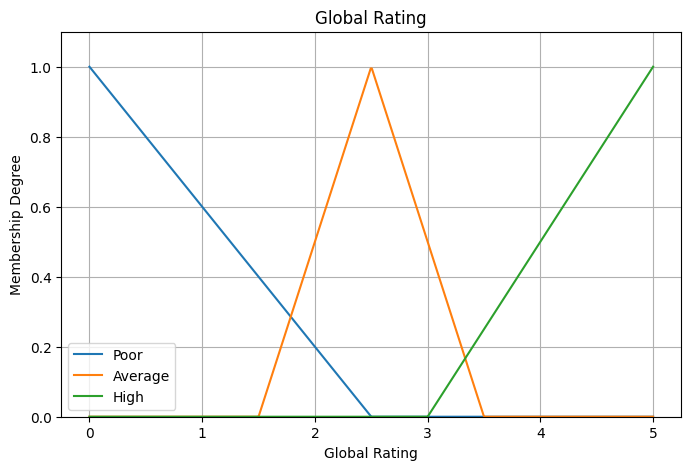

In [8]:
#The Graph bruh 

plt.figure(figsize=(8, 5))

plt.plot(x_global, mf_global['Poor'], label='Poor')
plt.plot(x_global, mf_global['Average'], label='Average')
plt.plot(x_global, mf_global['High'], label='High')

plt.title('Global Rating')
plt.xlabel('Global Rating')
plt.ylabel('Membership Degree')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

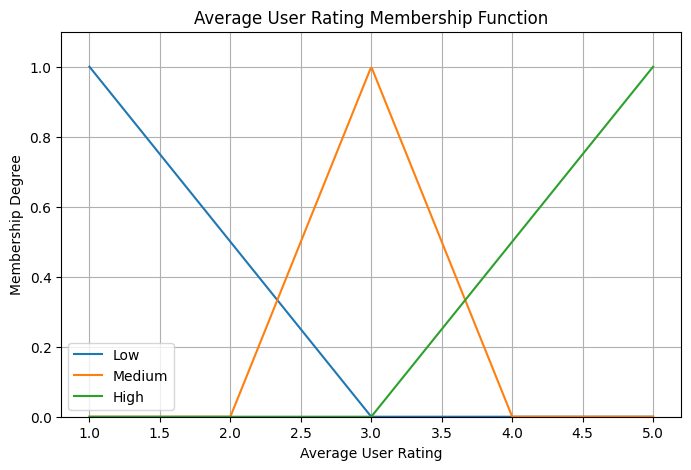

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(x_avg_user_rating, mf_avg_rating['Low'], label='Low')
plt.plot(x_avg_user_rating, mf_avg_rating['Medium'], label='Medium')
plt.plot(x_avg_user_rating, mf_avg_rating['High'], label='High')

plt.title('Average User Rating Membership Function')
plt.xlabel('Average User Rating')
plt.ylabel('Membership Degree')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

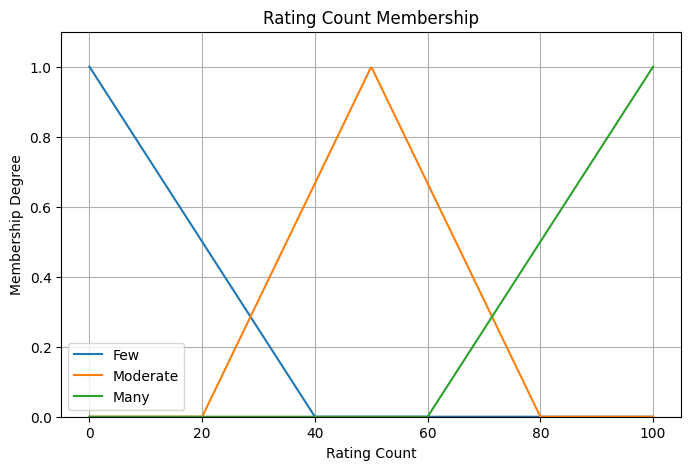

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(x_rating_count, mf_count['Few'], label='Few')
plt.plot(x_rating_count, mf_count['Moderate'], label='Moderate')
plt.plot(x_rating_count, mf_count['Many'], label='Many')

plt.title('Rating Count Membership')
plt.xlabel('Rating Count')
plt.ylabel('Membership Degree')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

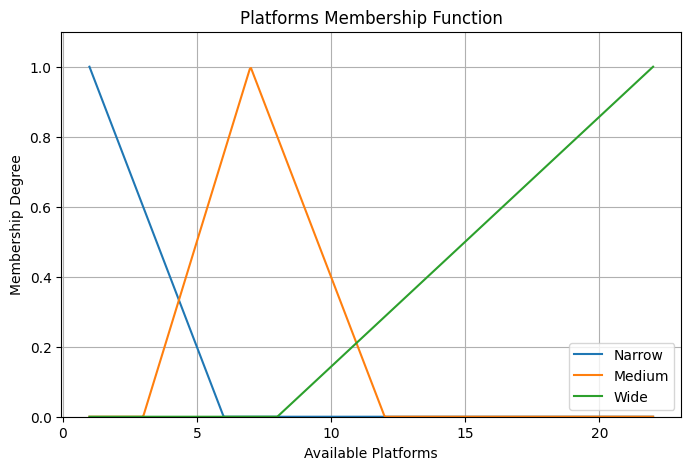

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(x_platform, mf_platform['Narrow'], label='Narrow')
plt.plot(x_platform, mf_platform['Medium'], label='Medium')
plt.plot(x_platform, mf_platform['Wide'], label='Wide')

plt.title('Platforms Membership Function')
plt.xlabel('Available Platforms')
plt.ylabel('Membership Degree')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

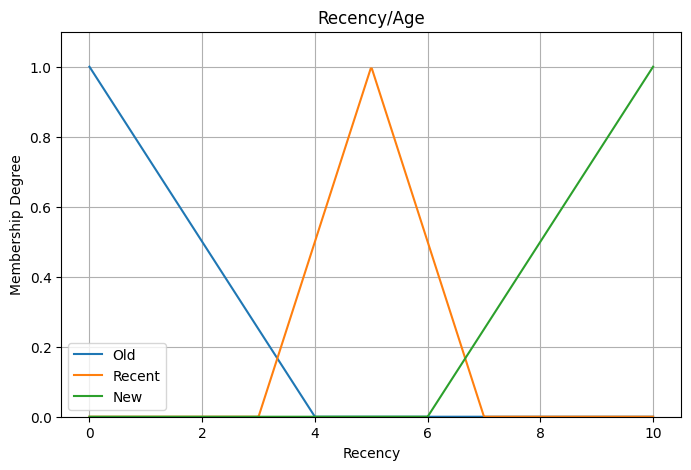

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(x_recent, mf_recent['Old'], label='Old')
plt.plot(x_recent, mf_recent['Recent'], label='Recent')
plt.plot(x_recent, mf_recent['New'], label='New')

plt.title('Recency/Age') #idk what to name this one 
plt.xlabel('Recency')
plt.ylabel('Membership Degree')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

---
## 2. Inference


In [13]:
#Output membership shapes (Mamdani implication)
out_x         = np.linspace(0, 10, 500)
out_poor      = trimf(out_x, [0, 0,  4 ])
out_fair      = trimf(out_x, [3, 5,  7 ])
out_excellent = trimf(out_x, [6, 10, 10])

In [14]:
#mayor mamdani

def mamdani_inference(fv):
    """
    Mamdani inference.
    fv : fuzzy values dict from fuzzify()
    Returns the aggregated output array (shape: 500,) ready for defuzzification.
    """
    rule_strengths = rule(fv)

    w_poor      = rule_strengths['Poor']
    w_decent    = rule_strengths['Decent']
    w_excellent = rule_strengths['Excellent']

    # Implication (min) 
    rule_poor      = np.minimum(w_poor,      out_poor)
    rule_decent    = np.minimum(w_decent,    out_fair)
    rule_excellent = np.minimum(w_excellent, out_excellent)

    # Aggregation (max) 
    aggregated = np.maximum(rule_poor, np.maximum(rule_decent, rule_excellent))
    return aggregated


In [15]:
#sugenoooooooooo

def sugeno_inference(fv):
    """
    Sugeno inference.
    fv : fuzzy values dict from fuzzify()
    Returns list of dicts with weight and output ready for defuzzification.
    """
    rule_strengths = rule(fv)

    OUT_POOR      = 0.0
    OUT_FAIR      = 5.0
    OUT_EXCELLENT = 10.0

    rules = [
        {'weight': rule_strengths['Poor'],      'output': OUT_POOR},
        {'weight': rule_strengths['Decent'],    'output': OUT_FAIR},
        {'weight': rule_strengths['Excellent'], 'output': OUT_EXCELLENT},
    ]
    return rules


---
## 3. Defuzzification


In [16]:
# Defuzzy  

def defuzzify_mamdani(x_output, aggregated_mf):
    """Centroid (Centre of Gravity) defuzzification for Mamdani."""
    numerator   = np.sum(x_output * aggregated_mf)
    denominator = np.sum(aggregated_mf)
    return numerator / denominator if denominator != 0 else 5.0

def defuzzify_sugeno(rules):
    """Weighted average defuzzification for Sugeno."""
    numerator   = sum(r['weight'] * r['output'] for r in rules)
    denominator = sum(r['weight'] for r in rules)
    return numerator / denominator if denominator != 0 else 5.0


---
## 4. Dataset Evaluation


Processing dataset rows through fuzzy engines...
Done. Processed 5000 games.

Mamdani -> MAE: 2.1323 | MSE: 6.7890
Sugeno  -> MAE: 2.3888 | MSE: 8.7214


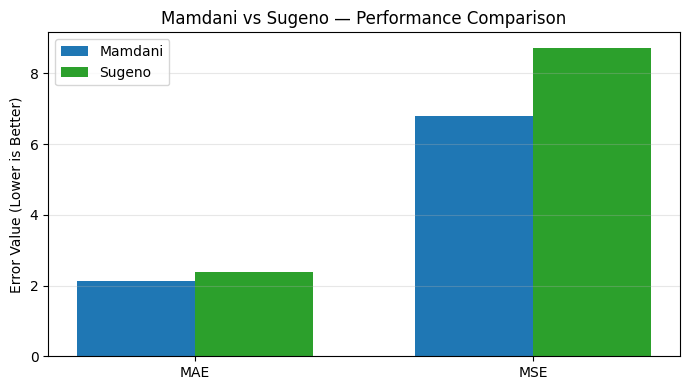

In [17]:
# Dataset Evaluation

mamdani_preds  = []
sugeno_preds   = []
actual_ratings = []

x_output = np.linspace(0, 10, 500)

print("Processing dataset rows through fuzzy engines...")

for index, row in data_games.iterrows():

    # Extract & clamp crisp inputs 

    # Global rating from metadata (0-5 scale, matches x_global universe)
    global_score = float(row.get('rating', 2.5))
    global_score = np.clip(global_score, 0, 5)

    # Average user rating from game_ratings (1-5 scale, matches x_avg_user_rating)
    avg_rating = float(row.get('avg_user_rating', global_score))
    avg_rating = np.clip(avg_rating, 1, 5)

    # Rating count from game_ratings (already capped at 100, matches x_rating_count)
    ratings_cnt = float(row.get('rating_count', 0))
    ratings_cnt = np.clip(ratings_cnt, 0, 100)

    # Platform count — platforms column is a comma-separated string (e.g. 'PC, Xbox, PS5')
    raw_platform = row.get('platforms', '')
    if isinstance(raw_platform, str) and raw_platform.strip():
        platform_cnt = len([p for p in raw_platform.split(',') if p.strip()])
    else:
        platform_cnt = 1
    platform_cnt = np.clip(platform_cnt, 1, 22)   # matches x_platform universe

    # Recency: convert release year to a 0-10 recency score
    # 10 = brand new (2026), 0 = very old (2016 or earlier)
    try:
        release_year = pd.to_datetime(row.get('released', '2016-01-01')).year
    except Exception:
        release_year = 2016
    game_age = np.clip(2026 - release_year, 0, 10)
    recency  = float(10 - game_age)               # matches x_recent universe [0, 10]

    # Fuzzify the crisp values
    fv = fuzzify(global_score, avg_rating, ratings_cnt, platform_cnt, recency)

    # Mamdani: inference → defuzzification 
    try:
        mamdani_agg = mamdani_inference(fv)
        m_crisp     = defuzzify_mamdani(x_output, mamdani_agg)
    except Exception:
        m_crisp = 5.0
    mamdani_preds.append(m_crisp)

    #Sugeno: inference → defuzzification
    try:
        sugeno_rules_out = sugeno_inference(fv)
        s_crisp          = defuzzify_sugeno(sugeno_rules_out)
    except Exception:
        s_crisp = 5.0
    sugeno_preds.append(s_crisp)

    actual_ratings.append(float(row.get('rating', 0)) * 2.0)

print(f"Done. Processed {len(mamdani_preds)} games.")


#Convert to arrays 
y_pred_m = np.array(mamdani_preds)
y_pred_s = np.array(sugeno_preds)
y_true   = np.array(actual_ratings)


#Error Metrics
m_mae = np.mean(np.abs(y_pred_m - y_true))
s_mae = np.mean(np.abs(y_pred_s - y_true))
m_mse = np.mean((y_pred_m - y_true) ** 2)
s_mse = np.mean((y_pred_s - y_true) ** 2)

print("\n" + "="*40)
print(f"Mamdani -> MAE: {m_mae:.4f} | MSE: {m_mse:.4f}")
print(f"Sugeno  -> MAE: {s_mae:.4f} | MSE: {s_mse:.4f}")
print("="*40)


#Performance Comparison Chart
metrics  = ['MAE', 'MSE']
m_scores = [m_mae, m_mse]
s_scores = [s_mae, s_mse]

x_pos = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_pos - width/2, m_scores, width, label='Mamdani', color='#1f77b4')
ax.bar(x_pos + width/2, s_scores, width, label='Sugeno',  color='#2ca02c')

ax.set_ylabel('Error Value (Lower is Better)')
ax.set_title('Mamdani vs Sugeno — Performance Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5. Sample Comparison


In [18]:
sample_names = [
    "The Witcher 3: Wild Hunt – Blood and Wine",
    "The Witcher 3 Wild Hunt - Complete Edition",
    "ARK: Survival Of The Fittest",
    "Homefront",
    "Super Magbot",
    "Boreal Blade",
    "DOOM (2016)",
    "Grand Theft Auto V",
]

sample_rows = []
for name in sample_names:
    row = data_games[data_games['name'] == name].iloc[0]

    global_score = float(np.clip(row['rating'], 0, 5))
    avg_rating   = float(np.clip(row['avg_user_rating'], 1, 5))
    ratings_cnt  = float(np.clip(row['rating_count'], 0, 100))

    raw_platform = row['platforms']
    if isinstance(raw_platform, str) and raw_platform.strip():
        platform_cnt = len([p for p in raw_platform.split(',') if p.strip()])
    else:
        platform_cnt = 1
    platform_cnt = np.clip(platform_cnt, 1, 22)

    try:
        release_year = pd.to_datetime(row['released']).year
    except Exception:
        release_year = 2016
    game_age = np.clip(2026 - release_year, 0, 10)
    recency  = float(10 - game_age)

    fv = fuzzify(global_score, avg_rating, ratings_cnt, platform_cnt, recency)

    m_pred = defuzzify_mamdani(x_output, mamdani_inference(fv))
    s_pred = defuzzify_sugeno(sugeno_inference(fv))
    actual = float(row['rating']) * 2.0

    sample_rows.append({'Game': name, 'Mamdani': round(m_pred, 2),
                         'Sugeno': round(s_pred, 2), 'Actual': round(actual, 2)})

sample_df = pd.DataFrame(sample_rows)
sample_df

,Game,Mamdani,Sugeno,Actual
0,The Witcher 3: Wild Hunt – Blood and Wine,3.52,2.86,9.62
1,The Witcher 3 Wild Hunt - Complete Edition,4.25,3.89,9.58
2,ARK: Survival Of The Fittest,4.46,4.37,5.18
3,Homefront,3.45,2.82,5.90
4,Super Magbot,2.72,1.41,0.00
5,Boreal Blade,3.10,2.18,0.00
6,DOOM (2016),4.37,3.88,8.76
7,Grand Theft Auto V,5.39,5.44,8.94


---
## 6. Steamlit UI


In [19]:
%%writefile app.py
import streamlit as st
import numpy as np

# --- PAGE CONFIG ---
st.set_page_config(page_title="Fuzzy Game Evaluator", page_icon="🎮", layout="centered")

# --- FUZZY LOGIC FROM NOTEBOOK ---
def trimf(x, abc):
    a, b, c = abc
    if a == b:
        return np.where(x < b, 0.0, np.where(x <= c, (c - x) / (c - b), 0.0))
    if b == c:
        return np.where(x < a, 0.0, np.where(x <= b, (x - a) / (b - a), 0.0))
    first_half = (x - a) / (b - a)
    second_half = (c - x) / (c - b)
    return np.maximum(0, np.minimum(first_half, second_half))

out_x         = np.linspace(0, 10, 500)
out_poor      = trimf(out_x, [0, 0,  4 ])
out_fair      = trimf(out_x, [3, 5,  7 ])
out_excellent = trimf(out_x, [6, 10, 10])

def fuzzify(global_in, avg_rating_in, count_in, platform_in, recent_in):
    return {
        'global': {
            'Poor'    : float(trimf(global_in, [0,   0,   2.5])),
            'Average' : float(trimf(global_in, [1.5, 2.5, 3.5])),
            'High'    : float(trimf(global_in, [3,   5,   5  ])),
        },
        'avg_rating': {
            'Low'    : float(trimf(avg_rating_in, [1, 1, 3])),
            'Medium' : float(trimf(avg_rating_in, [2, 3, 4])),
            'High'   : float(trimf(avg_rating_in, [3, 5, 5])),
        },
        'count': {
            'Few'      : float(trimf(count_in, [0,  0,   40 ])),
            'Moderate' : float(trimf(count_in, [20, 50,  80 ])),
            'Many'     : float(trimf(count_in, [60, 100, 100])),
        },
        'platform': {
            'Narrow' : float(trimf(platform_in, [1, 1,  6 ])),
            'Medium' : float(trimf(platform_in, [3, 7,  12])),
            'Wide'   : float(trimf(platform_in, [8, 22, 22])),
        },
        'recent': {
            'Old'    : float(trimf(recent_in, [0, 0,  4 ])),
            'Recent' : float(trimf(recent_in, [3, 5,  7 ])),
            'New'    : float(trimf(recent_in, [6, 10, 10])),
        },
    }

def fuzzy_and(*args): 
    return min(args)
def fuzzy_or(*args): 
    return max(args)

def rule(fuzzyValues) : 
    poor_rules = [
        fuzzy_or(fuzzyValues['global']['Poor'], fuzzyValues['avg_rating']['Low']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['avg_rating']['Low'], fuzzyValues['platform']['Narrow']),
        fuzzy_and(fuzzyValues['recent']['Old'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['avg_rating']['Low'], fuzzyValues['recent']['Old']),
        fuzzy_and(fuzzyValues['global']['Poor'], fuzzyValues['platform']['Narrow']),
        fuzzy_and(fuzzyValues['avg_rating']['Low'], fuzzyValues['count']['Few'])
    ]
    decent_rules = [
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['avg_rating']['Medium']),
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['count']['Moderate']),
        fuzzy_and(fuzzyValues['avg_rating']['Medium'], fuzzyValues['count']['Moderate']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['count']['Few']),
        fuzzy_and(fuzzyValues['avg_rating']['Medium'], fuzzyValues['platform']['Medium']),
        fuzzy_and(fuzzyValues['recent']['Recent'], fuzzyValues['avg_rating']['Medium']),
        fuzzy_and(fuzzyValues['global']['Average'], fuzzyValues['platform']['Medium'])
    ]
    excellent_rules = [
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['recent']['New'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many'], fuzzyValues['recent']['New']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High'], fuzzyValues['count']['Many'], fuzzyValues['platform']['Wide']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['avg_rating']['High']),
        fuzzy_and(fuzzyValues['global']['High'], fuzzyValues['platform']['Wide'])
    ]
    return {
        'Poor': max(poor_rules),
        'Decent' : max(decent_rules), 
        'Excellent' : max(excellent_rules)
    }

def mamdani_inference(fv):
    rule_strengths = rule(fv)
    rule_poor      = np.minimum(rule_strengths['Poor'],      out_poor)
    rule_decent    = np.minimum(rule_strengths['Decent'],    out_fair)
    rule_excellent = np.minimum(rule_strengths['Excellent'], out_excellent)
    return np.maximum(rule_poor, np.maximum(rule_decent, rule_excellent))

def sugeno_inference(fv):
    rule_strengths = rule(fv)
    return [
        {'weight': rule_strengths['Poor'],      'output': 0.0},
        {'weight': rule_strengths['Decent'],    'output': 5.0},
        {'weight': rule_strengths['Excellent'], 'output': 10.0},
    ]

def defuzzify_mamdani(x_output, aggregated_mf):
    numerator   = np.sum(x_output * aggregated_mf)
    denominator = np.sum(aggregated_mf)
    return numerator / denominator if denominator != 0 else 5.0

def defuzzify_sugeno(rules):
    numerator   = sum(r['weight'] * r['output'] for r in rules)
    denominator = sum(r['weight'] for r in rules)
    return numerator / denominator if denominator != 0 else 5.0

#
st.title("🎮 Video Game Performance Evaluator")
st.markdown("This application evaluates games using the DKA Project's **Fuzzy Logic Framework**.")

st.sidebar.header("🕹️ Input Game Parameters")
global_score = st.sidebar.slider("Global Rating (0-5)", 0.0, 5.0, 2.5)
avg_rating = st.sidebar.slider("User Rating (1-5)", 1.0, 5.0, 3.0)
platforms = st.sidebar.slider("Number of Platforms", 1, 22, 5)
ratings_cnt = st.sidebar.slider("Rating Count", 0, 100, 50)
recency = st.sidebar.slider("Recency (0=Old, 10=New)", 0.0, 10.0, 5.0)

col1, col2, col3, col4, col5 = st.columns(5)
col1.metric("Global", global_score)
col2.metric("User", avg_rating)
col3.metric("Platforms", platforms)
col4.metric("Count", ratings_cnt)
col5.metric("Recency", recency)

st.write("---")

if st.button("Calculate Performance", type="primary"):
    with st.spinner("Processing through Fuzzy Inference System..."):
        fv = fuzzify(global_score, avg_rating, ratings_cnt, platforms, recency)
        
        m_pred = defuzzify_mamdani(out_x, mamdani_inference(fv))
        s_pred = defuzzify_sugeno(sugeno_inference(fv))
        
        st.success("Evaluation Complete!")
        c1, c2 = st.columns(2)
        c1.write("### Mamdani System Prediction:")
        c1.markdown(f"<h2 style='color: #4CAF50;'>{round(m_pred, 2)} / 10</h2>", unsafe_allow_html=True)
        c2.write("### Sugeno System Prediction:")
        c2.markdown(f"<h2 style='color: #2196F3;'>{round(s_pred, 2)} / 10</h2>", unsafe_allow_html=True)

Overwriting app.py


---
## 7. Fuzzy Logic + Machine Learning


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Training Hybrid Fuzzy-Random Forest Model")

hybrid_data = pd.DataFrame({
    'Global_Score': np.clip(data_games['rating'].fillna(2.5), 0, 5),
    'Avg_Rating': np.clip(data_games['avg_user_rating'].fillna(data_games['rating']), 1, 5),
    'Rating_Count': np.clip(data_games['rating_count'].fillna(0), 0, 100),
    'Mamdani_Output': mamdani_preds,  
    'Sugeno_Output': sugeno_preds,    
    'Actual_Performance': actual_ratings
})

features = ['Global_Score', 'Avg_Rating', 'Rating_Count', 'Mamdani_Output', 'Sugeno_Output']
X = hybrid_data[features]
y = hybrid_data['Actual_Performance']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ml_hybrid = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
ml_hybrid.fit(X_train, y_train)


predictions = ml_hybrid.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"[+] Hybrid ML Model Trained on {len(X_train)} samples!")
print(f"[*] ML Mean Absolute Error (MAE): {mae:.4f}")
print(f"[*] ML Root Mean Squared Error (RMSE): {rmse:.4f}")

Training Hybrid Fuzzy-Random Forest Model
[+] Hybrid ML Model Trained on 4000 samples!
[*] ML Mean Absolute Error (MAE): 0.0088
[*] ML Root Mean Squared Error (RMSE): 0.0206


---
## 8. Fuzzy Logic + Deep Learning


=== Training Hybrid Fuzzy-Deep Learning Model ===
Training Neural Network... (50 Epochs)


C:\Users\ASUS\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[+] Hybrid DL Model Trained!
[*] Deep Learning Mean Absolute Error (MAE): 0.2376



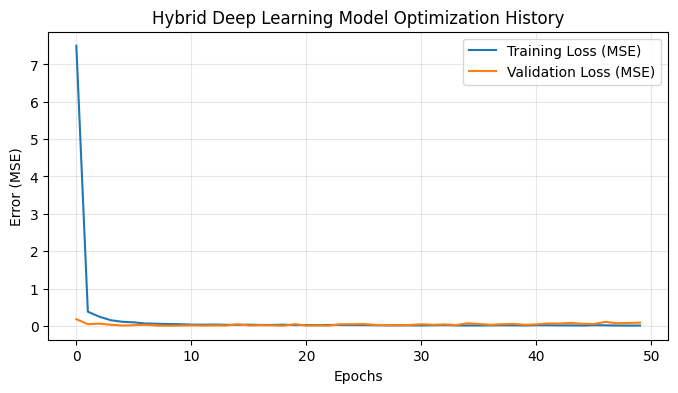

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("=== Training Hybrid Fuzzy-Deep Learning Model ===")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dl_hybrid = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1], name="Input_Layer_including_Fuzzy"),
    Dropout(0.2),
    Dense(32, activation='relu', name="Hidden_Layer_1"),
    Dense(16, activation='relu', name="Hidden_Layer_2"),
    Dense(1, activation='linear', name="Final_Output") 
])

# --- 3. COMPILE THE MODEL ---
dl_hybrid.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
                  loss='mse', 
                  metrics=['mae'])

# --- 4. TRAIN THE MODEL ---
print("Training Neural Network... (50 Epochs)")
history = dl_hybrid.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=0 # Change to 1 to see the epoch loading bar
)

# --- 5. EVALUATE AND VISUALIZE ---
dl_loss, dl_mae = dl_hybrid.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n[+] Hybrid DL Model Trained!")
print(f"[*] Deep Learning Mean Absolute Error (MAE): {dl_mae:.4f}")

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Hybrid Deep Learning Model Optimization History')
plt.xlabel('Epochs')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()